In [27]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")

CUDA: True
GPU : Tesla T4


# Imports & Config

In [28]:
!pip install ultralytics -q

import os, cv2, h5py, random, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as TF
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from sklearn.cluster import DBSCAN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, classification_report
from ultralytics import YOLO

warnings.filterwarnings('ignore')
torch.set_warn_always(False)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATASET_PATH   = "/kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000"
RLVS_RAW_DIR   = '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset'
RWF_TRAIN_HDF5 = '/kaggle/input/datasets/howldg/dataset1/rwf2000_train.h5'
RWF_VAL_HDF5   = '/kaggle/input/datasets/howldg/dataset1/rwf2000_val.h5'
RLVS_HDF5      = '/kaggle/working/rlvs.h5'
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
RESULTS_PATH   = '/kaggle/working/fold_results.json'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── HDF5 ──────────────────────────────────────────────────────────────────────
NUM_FRAMES_STORED = 64
NUM_FRAMES_SAMPLE = 32
IMG_SIZE          = 224

# ── Training ──────────────────────────────────────────────────────────────────
# Hyperparameters tuned for MA-X3D v2 (learnable temporal kernel) on RWF-2000:
#   - K_FOLDS=3: fits in one 12-h Kaggle session; less reliable mean than 5-fold
#                but each fold has more val samples (~533 vs ~320) so per-fold
#                accuracy is actually a bit more stable.
#   - NUM_EPOCHS=16: empirical best on v1 was around epoch 10; 16 gives ample
#                headroom for patience without wasting compute.
#   - PATIENCE=5: standard for cosine schedules with ~13 finetune epochs.
#   - WEIGHT_DECAY=5e-4: reduced from 1e-3 because v2 augmentation (9 stochastic
#                ops, see VideoTransform) already provides strong regularisation;
#                stacking more weight decay risks underfitting.
#   - Discriminative LR (probe -> finetune):
#       LR_PROBE = 1e-3  → both head proj AND motion_attn at probe rate.
#       LR_FINETUNE = 1e-5 → pretrained backbone (blocks 0-4): tiny LR.
#       LR_MA       = 5e-4 → newly-added modules (head proj + motion_attn):
#                            50x backbone LR so they keep learning during
#                            finetune. Without this, the new gate/proj barely
#                            move once we drop to 1e-5 — a known issue when
#                            mixing random-init heads with pretrained features
#                            (BiT, timm recipes).
AUGMENT_MULTIPLIER = 1    # 1600x2 = 3200 steps/epoch (~25-35 min/epoch on T4)
K_FOLDS            = 5
NUM_EPOCHS         = 29
BATCH_SIZE         = 20
FREEZE_EPOCHS      = 3
PATIENCE           = 25
LR_PROBE           = 1e-3
LR_FINETUNE        = 1e-5     # pretrained backbone during finetune
LR_MA              = 5e-4     # new modules (motion_attn + head proj) during finetune
WEIGHT_DECAY       = 5e-4
NUM_WORKERS        = 4

# --- v3: MEAA (CUE-Net) + EMA + train dai hon (1 lan train, dung HDF5 cu) ---
USE_EAA    = True     # Efficient Additive Attention sau Res5 (global token-mix, identity-init)
USE_EMA    = True     # EMA trong so; eval + save best tren ban EMA
EMA_DECAY  = 0.999
WK_TRAIN_BASE  = True   # False = early-stage (Res2/Res3) CHI train WK delta, freeze base (it overfit hon)
FREEZE_BN_EVAL = True    # BN cua stage dong cung -> eval(): running-stats khong troi tren data moi
HEAD_DROPOUT      = 0.3   # MSTFDet ablate 0.3 toi uu (0.5 over-regularize tren data nho)
USE_CUTMIX        = True  # CutMix frame-consistent (regularizer)
CUTMIX_PROB       = 0.5
CUTMIX_ALPHA      = 1.0
MOTION_MULTISCALE = True  # motion da-scale: max(|dt=1|,|dt=2|), van 1 kenh (khong doi arch)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device  : {DEVICE}")
print(f"Batch   : {BATCH_SIZE}  Aug x{AUGMENT_MULTIPLIER}  Workers={NUM_WORKERS}")
print(f"Epochs  : {NUM_EPOCHS}  (freeze={FREEZE_EPOCHS}, patience={PATIENCE})")
print(f"K-Folds : {K_FOLDS}  - all folds run sequentially, checkpoint each epoch")
print(f"LR      : probe={LR_PROBE:.0e}  finetune_backbone={LR_FINETUNE:.0e}  finetune_new={LR_MA:.0e}")
print(f"WD      : {WEIGHT_DECAY:.0e}")


Device  : cuda
Batch   : 20  Aug x1  Workers=4
Epochs  : 29  (freeze=3, patience=25)
K-Folds : 5  - all folds run sequentially, checkpoint each epoch
LR      : probe=1e-03  finetune_backbone=1e-05  finetune_new=5e-04
WD      : 5e-04


In [29]:
# ── Resume from previous session ─────────────────────────────────────────────
import shutil

# Point to your previous notebook output saved as dataset
PREV_OUTPUT = '/kaggle/input/datasets/huuhoang2707/x3dv51'  # <- change to match your dataset name

if os.path.exists(PREV_OUTPUT):
    # Restore checkpoints
    ckpt_src = os.path.join(PREV_OUTPUT, 'checkpoints')
    if os.path.exists(ckpt_src):
        for f in os.listdir(ckpt_src):
            dst = os.path.join(CHECKPOINT_DIR, f)
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(ckpt_src, f), dst)
                print(f'  Restored: {f}')
    # Restore fold results
    for name in ['fold_results.json', 'fold_results_ma.json', 'experiments_log.xlsx']:
        src_f = os.path.join(PREV_OUTPUT, name)
        dst_f = os.path.join('/kaggle/working', name)
        if os.path.exists(src_f) and not os.path.exists(dst_f):
            shutil.copy2(src_f, dst_f)
            print(f'  Restored: {name}')
    print('Resume complete.')
else:
    print(f'No previous output at {PREV_OUTPUT} — training from scratch')


Resume complete.


# Preprocessing

In [30]:
# Shared CLAHE object — created once, reused for every frame
_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    """Denoise + CLAHE contrast enhancement (BGR in, BGR out)."""
    denoised = cv2.bilateralFilter(frame, 5, 50, 50)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    lab = cv2.merge((_CLAHE.apply(l), a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def extract_dense_frames(video_path: str, num_frames: int = 64,
                          clip_duration: float = None) -> np.ndarray | None:
    """
    Sequential read for maximum speed.
    clip_duration=5.0  → center 5s window (RWF-2000, short CCTV clips)
    clip_duration=None → full video      (RLVS, longer YouTube clips)
    Returns [T, H, W, 3] RGB or None on failure.
    """
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0

    if total <= 0:
        cap.release()
        return None

    if clip_duration:
        window = int(fps * clip_duration)
        center = total // 2
        start  = max(0, center - window // 2)
        end    = min(total - 1, center + window // 2)
    else:
        start, end = 0, total - 1

    indices    = np.linspace(start, end, num_frames, dtype=int).tolist()
    target_set = set(indices)
    store      = {}

    cur = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if cur in target_set:
            store[cur] = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        cur += 1
        if cur > end:
            break
    cap.release()

    frames = [store[i] for i in indices if i in store]
    if not frames:
        return None
    while len(frames) < num_frames:
        frames.append(frames[-1])
    return np.array(frames[:num_frames])


# ROI cropping mode (thi nghiem hoc tu CUE-Net):
#   'cluster'   : chon cum DBSCAN dong nhat + margin (MA-X3D mac dinh).
#   'union_all' : bbox bao TAT CA nguoi phat hien (CUE-Net style);
#                 <=1 detection -> full frame (giong CUE-Net fallback).
# Doi sang 'union_all' roi BUILD LAI HDF5 (path moi) + train lai de ablation.
ROI_MODE = 'cluster'


def get_roi(frames: list, yolo_model, n_sample: int = 12,
            margin: float = 0.2, mode: str = None) -> tuple:
    """
    Temporal Point-Cloud ROI tu YOLOv8 person detection tren n_sample frame deu nhau.
      mode='cluster'   : chon cum DBSCAN dong nhat (mac dinh).
      mode='union_all' : bao TAT CA nguoi (CUE-Net); <=1 nguoi -> full frame.
    Returns (x1, y1, x2, y2). Default mode lay tu bien toan cuc ROI_MODE.
    """
    mode = mode or ROI_MODE
    idxs   = np.linspace(0, len(frames) - 1, n_sample, dtype=int)
    sample = [frames[i] for i in idxs]
    h, w, _ = sample[0].shape
    eps    = int(max(w, h) * 0.15)

    results        = yolo_model(sample, classes=[0], verbose=False)
    boxes, centers = [], []
    for res in results:
        if res.boxes is None:
            continue
        for box in res.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            boxes.append((x1, y1, x2, y2))
            centers.append([(x1 + x2) // 2, (y1 + y2) // 2])

    if not boxes:
        return 0, 0, w, h

    # --- CUE-Net style: bbox bao TAT CA nguoi; <=1 detection -> full frame ---
    if mode == 'union_all':
        if len(boxes) < 2:
            return 0, 0, w, h
        min_x, min_y = min(b[0] for b in boxes), min(b[1] for b in boxes)
        max_x, max_y = max(b[2] for b in boxes), max(b[3] for b in boxes)
        dx = int((max_x - min_x) * margin)
        dy = int((max_y - min_y) * margin)
        return (max(0, min_x-dx), max(0, min_y-dy),
                min(w, max_x+dx), min(h, max_y+dy))

    # --- MA-X3D default: DBSCAN cum dong nhat ---
    if len(boxes) < 2:
        x1, y1, x2, y2 = boxes[0]
        return max(0, x1-50), max(0, y1-50), min(w, x2+50), min(h, y2+50)

    lbl    = DBSCAN(eps=eps, min_samples=2).fit(centers).labels_
    best   = max((l for l in set(lbl) if l != -1),
                  key=lambda l: int(np.sum(lbl == l)), default=-1)
    chosen = [b for b, l in zip(boxes, lbl) if l == best] if best != -1 else boxes

    min_x, min_y = min(b[0] for b in chosen), min(b[1] for b in chosen)
    max_x, max_y = max(b[2] for b in chosen), max(b[3] for b in chosen)
    dx = int((max_x - min_x) * margin)
    dy = int((max_y - min_y) * margin)
    return (max(0, min_x-dx), max(0, min_y-dy),
            min(w, max_x+dx), min(h, max_y+dy))


def create_hdf5_dataset(base_dir: str, output_path: str, yolo_model,
                         num_frames: int = 64, size: tuple = (224, 224),
                         clip_duration: float = None):
    """
    Build compressed HDF5 from raw videos. Append mode supports resume.
    clip_duration: pass 5.0 for RWF-2000, None for RLVS (full video).
    """
    with h5py.File(output_path, 'a') as hf:
        for cls in ['Fight', 'NonFight']:
            cls_dir = os.path.join(base_dir, cls)
            if not os.path.exists(cls_dir):
                print(f"[SKIP] Not found: {cls_dir}")
                continue

            videos = sorted(v for v in os.listdir(cls_dir)
                            if v.endswith(('.mp4', '.avi')))
            dset   = hf[cls] if cls in hf else hf.create_dataset(
                cls, shape=(len(videos), num_frames, 3, size[0], size[1]),
                dtype=np.uint8, compression='gzip', compression_opts=4)

            print(f"Processing {cls} — {len(videos)} videos  clip={clip_duration}s")
            for i, vname in enumerate(tqdm(videos, desc=cls)):
                if np.any(dset[i, 0]):          # resume: skip written
                    continue
                frames = extract_dense_frames(
                    os.path.join(cls_dir, vname), num_frames, clip_duration)
                if frames is None:
                    continue
                x1, y1, x2, y2 = get_roi(list(frames), yolo_model)
                out = []
                for f in frames:
                    h_, w_, _ = f.shape
                    crop = f[max(0,y1):min(h_,y2), max(0,x1):min(w_,x2)]
                    crop = f if crop.size == 0 else crop
                    out.append(np.transpose(cv2.resize(preprocess_frame(crop), size), (2,0,1)))
                dset[i] = np.array(out, dtype=np.uint8)

    print(f"Saved → {output_path}")


# Data Testing

In [31]:
yolo_model = YOLO('yolov8n.pt')
yolo_model.to(DEVICE)

def get_random_video(dataset_path):
    videos = (glob(os.path.join(dataset_path, "train/Fight/*.avi")) +
              glob(os.path.join(dataset_path, "train/NonFight/*.avi")))
    return random.choice(videos)

def _read_equidistant(video_path, num_frames=32):
    """Quick random-seek reader for visualization only."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []
    for idx in np.linspace(0, total - 1, num_frames, dtype=int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, f = cap.read()
        if ret:
            h, w = f.shape[:2]
            if w > 640:
                f = cv2.resize(f, (640, int(h * 640 / w)), interpolation=cv2.INTER_AREA)
            frames.append(f)
    cap.release()
    while len(frames) < num_frames and frames:
        frames.append(frames[-1].copy())
    return frames

video_path = get_random_video(DATASET_PATH)
print("Video:", video_path)
frames = _read_equidistant(video_path, NUM_FRAMES_SAMPLE)

Video: /kaggle/input/datasets/vulamnguyen/rwf2000/RWF-2000/train/NonFight/JwfajujK_0.avi


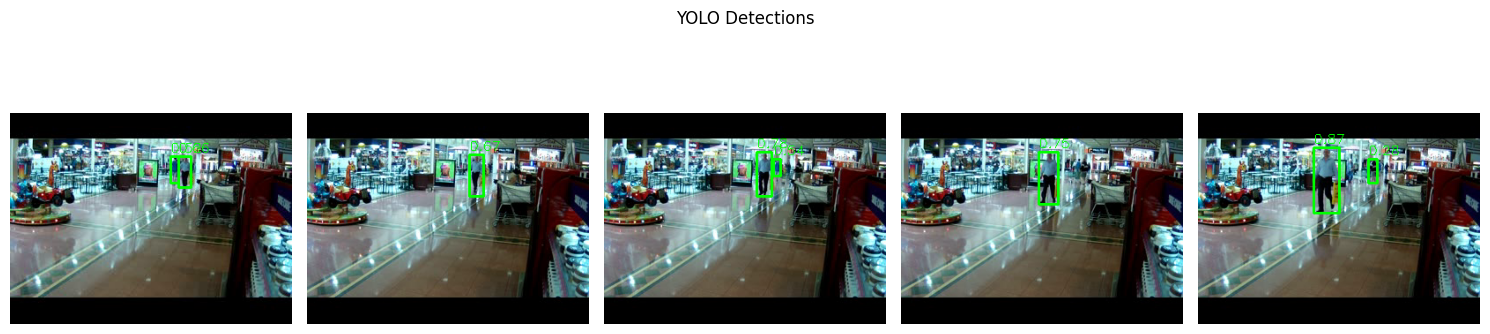

ROI: (114, 26, 235, 128)


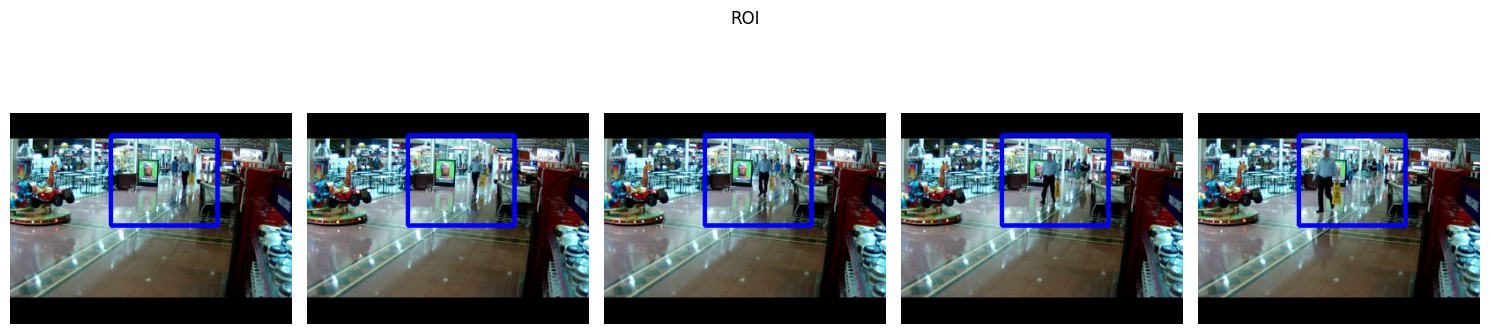

In [32]:
def show_yolo_detections(frames, model, n=5):
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(np.linspace(0, len(frames)-1, n, dtype=int)):
        frame = frames[idx].copy()
        for box in model(frame, classes=[0], verbose=False)[0].boxes:
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            conf = float(box.conf[0])
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)
            cv2.putText(frame, f"{conf:.2f}", (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        plt.subplot(1, n, i+1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.suptitle("YOLO Detections")
    plt.tight_layout()
    plt.show()

def show_roi_overlay(frames, roi, n=5):
    x1, y1, x2, y2 = roi
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(np.linspace(0, len(frames)-1, n, dtype=int)):
        frame = frames[idx].copy()
        cv2.rectangle(frame, (x1,y1), (x2,y2), (255,0,0), 3)
        plt.subplot(1, n, i+1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if frame.ndim == 3 else frame)
        plt.axis('off')
    plt.suptitle("ROI")
    plt.tight_layout()
    plt.show()

show_yolo_detections(frames, yolo_model)
roi = get_roi(frames, yolo_model)
print("ROI:", roi)
show_roi_overlay(frames, roi)

# Build HDF5 — RWF-2000

In [33]:
# ── Build HDF5 for RWF-2000 ───────────────────────────────────────────────────
# clip_duration=5.0: CCTV clips are 5-10s, center window captures the action.
# Run once — resume-safe (skips already-written videos).

for split, out_path in [('train', RWF_TRAIN_HDF5), ('val', RWF_VAL_HDF5)]:
    src = os.path.join(DATASET_PATH, split)
    if not os.path.exists(src):
        print(f"[SKIP] Source not found: {src}")
        continue
    if os.path.exists(out_path):
        print(f"[SKIP] Already exists: {out_path}")
        continue
    print(f"Building {split} HDF5...")
    create_hdf5_dataset(src, out_path, yolo_model,
                         num_frames=NUM_FRAMES_STORED, clip_duration=5.0)


[SKIP] Already exists: /kaggle/input/datasets/howldg/dataset1/rwf2000_train.h5
[SKIP] Already exists: /kaggle/input/datasets/howldg/dataset1/rwf2000_val.h5


# Build HDF5 — RLVS (optional)

In [34]:
# ── Build HDF5 for RLVS (optional) ───────────────────────────────────────────
# clip_duration=None: YouTube clips can be 20-60s, action is not centered.

if not os.path.exists(RLVS_RAW_DIR):
    print("[SKIP] RLVS raw data not found — add dataset in Kaggle input")
elif os.path.exists(RLVS_HDF5):
    print(f"[SKIP] Already exists: {RLVS_HDF5}")
else:
    link_dir = '/kaggle/working/RLVS_Linked'
    os.makedirs(link_dir, exist_ok=True)
    for src_name, dst_name in [('Violence', 'Fight'), ('NonViolence', 'NonFight')]:
        s = os.path.join(RLVS_RAW_DIR, src_name)
        d = os.path.join(link_dir, dst_name)
        if os.path.exists(s) and not os.path.exists(d):
            os.symlink(s, d)
    print("Building RLVS HDF5...")
    create_hdf5_dataset(link_dir, RLVS_HDF5, yolo_model,
                         num_frames=NUM_FRAMES_STORED, clip_duration=None)


[SKIP] RLVS raw data not found — add dataset in Kaggle input


# Dataset & Augmentation

In [35]:
from torch.utils.data import WeightedRandomSampler
import torchvision.transforms.functional as TF


class TemporalSampler:
    """
    Training : random window + random speed (0.7-1.5x) + jitter.
    Eval     : uniform spacing, deterministic.
    """
    def __init__(self, num_stored=64, num_output=32, training=True):
        self.T, self.n, self.training = num_stored, num_output, training

    def __call__(self):
        if not self.training:
            return np.linspace(0, self.T - 1, self.n, dtype=int)
        start = random.randint(0, max(0, self.T - self.n))
        span  = np.clip(int(self.n * random.uniform(0.7, 1.5)),
                        self.n // 2, self.T - start)
        if span < 2:
            return np.linspace(0, self.T - 1, self.n, dtype=int)
        base   = np.linspace(start, start + span - 1, self.n)
        jitter = np.random.randint(-1, 2, self.n)
        return np.sort(np.clip(base + jitter, 0, self.T - 1).astype(int))


# Ablation flags for VideoTransform (top-level, easy to flip)
USE_INVERSE  = False   # Paper SepConvLSTM default True at 15%; OFF here (violence causality)
ROTATION_DEG = 10      # Paper default 25; reduced for static CCTV


class VideoTransform:
    """
    Augmentation on [C, T, H, W] tensor in [0, 1].
    Adapted from zahid58/SepConvLSTM (Islam 2021) with two domain-aware
    modifications for static-camera surveillance:
      - rotation_deg=10   (paper used 25; CCTV is stationary)
      - use_inverse=False (paper used True at 15%; violates causality)

    Pipeline (in order):
      1. Random brightness   U(0.5, 1.5)         -- 100%
      2. Saturation jitter   +/- 0.3             -- 100%
      3. Value shift         +/- 40/255          -- 100%
      4. Horizontal flip                         --  50%
      5. Random crop + bilinear resize           --  80%
      6. Random rotation +/-rotation_deg         --  80%
      7. Inverse temporal order                  --  15% (only if use_inverse)
      8. Temporal upsample/downsample            --  50%
      9. Gaussian blur (sigma 1-2)               --  20%
    """
    def __init__(self, training=True, use_inverse=USE_INVERSE,
                 rotation_deg=ROTATION_DEG):
        self.training      = training
        self.use_inverse   = use_inverse
        self.rotation_deg  = rotation_deg

    def __call__(self, x):
        if not self.training:
            return x

        C, T, H, W = x.shape

        # 1. Random brightness (always)
        x = torch.clamp(x * random.uniform(0.5, 1.5), 0, 1)

        # 2. Saturation jitter (HSV-equivalent via grayscale mixing)
        sat_f = 1.0 + random.uniform(-0.3, 0.3)
        gray  = x.mean(dim=0, keepdim=True)                          # [1, T, H, W]
        x     = torch.clamp(gray + sat_f * (x - gray), 0, 1)

        # 3. Value shift (HSV V-channel offset proxy)
        val_o = random.uniform(-40, 40) / 255.0
        x     = torch.clamp(x + val_o, 0, 1)

        # 4. Horizontal flip 0.5
        if random.random() < 0.5:
            x = x.flip(-1)

        # 5. Random crop + resize back, prob 0.8
        if random.random() < 0.8:
            scale  = random.uniform(0.7, 1.0)
            nh, nw = int(H * scale), int(W * scale)
            top    = random.randint(0, H - nh)
            left   = random.randint(0, W - nw)
            cropped = x[:, :, top:top+nh, left:left+nw]              # [C, T, nh, nw]
            cropped = cropped.permute(1, 0, 2, 3)                    # [T, C, nh, nw]
            cropped = torch.nn.functional.interpolate(
                cropped, size=(H, W), mode='bilinear', align_corners=False)
            x = cropped.permute(1, 0, 2, 3)                          # [C, T, H, W]

        # 6. Random rotation +/-rotation_deg, prob 0.8
        if self.rotation_deg > 0 and random.random() < 0.8:
            angle = random.uniform(-self.rotation_deg, self.rotation_deg)
            x_t = x.permute(1, 0, 2, 3)                              # [T, C, H, W]
            x_t = TF.rotate(x_t, angle,
                             interpolation=TF.InterpolationMode.BILINEAR)
            x = x_t.permute(1, 0, 2, 3)

        # 7. Inverse temporal — OFF by default (causality concern)
        if self.use_inverse and random.random() < 0.15:
            x = x.flip(1)

        # 8. Temporal upsample/downsample, prob 0.5
        if random.random() < 0.5:
            ratio = random.uniform(0.7, 1.3)
            new_T = max(int(T * ratio), 16)
            idxs  = torch.linspace(0, T - 1, new_T).long()
            tmp   = x[:, idxs]
            idxs2 = torch.linspace(0, new_T - 1, T).long()
            x     = tmp[:, idxs2]

        # 9. Gaussian blur, prob 0.2
        if random.random() < 0.2:
            sigma = random.uniform(1, 2)
            ksize = max(3, int(2 * np.ceil(2 * sigma) + 1))
            if ksize % 2 == 0:
                ksize += 1
            x_t = x.permute(1, 0, 2, 3)                              # [T, C, H, W]
            x_t = TF.gaussian_blur(x_t, kernel_size=ksize, sigma=sigma)
            x = x_t.permute(1, 0, 2, 3)

        return torch.clamp(x, 0, 1)


class HDF5VideoDataset(Dataset):
    """
    Zero-copy streaming from HDF5. Returns (video, motion, label).
    Motion mask = |frame[t] - frame[t-1]| averaged across channels, computed
    AFTER augmentation so it stays aligned with the augmented RGB.
    """
    def __init__(self, h5_files, transform=None,
                 num_stored=64, num_sample=32,
                 training=True, augment_multiplier=1):

        if isinstance(h5_files, str):
            h5_files = [h5_files]

        self.transform          = transform
        self.training           = training
        self.augment_multiplier = augment_multiplier if training else 1
        self.num_sample         = num_sample
        self.files              = []
        self.records            = []
        actual_T                = 0

        for fid, path in enumerate(h5_files):
            try:
                hf = h5py.File(path, 'r')
                self.files.append(None)
                self._paths = getattr(self, "_paths", [])
                self._paths.append(path)
                nf = nn_ = 0
                for cls, lbl in [('Fight', 1), ('NonFight', 0)]:
                    if cls in hf:
                        n        = hf[cls].shape[0]
                        actual_T = hf[cls].shape[1]
                        self.records.extend((fid, cls, i, lbl, fid) for i in range(n))
                        if lbl == 1: nf = n
                        else:        nn_ = n
                print(f"  [src={fid}] {path.split('/')[-1]} - Fight:{nf} NonFight:{nn_} T={actual_T}")
            except Exception as e:
                print(f"  [WARN] Cannot open {path}: {e}")
                self.files.append(None)

        self.sampler   = TemporalSampler(actual_T or num_stored, num_sample, training)
        self.base_len  = len(self.records)
        self.total_len = self.base_len * self.augment_multiplier
        print(f"  -> {self.base_len} videos x {self.augment_multiplier} = {self.total_len} samples/epoch")

    def __len__(self):
        return self.total_len

    def _get_file(self, fid):
        if self.files[fid] is None:
            self.files[fid] = h5py.File(self._paths[fid], 'r')
        return self.files[fid]

    def __getitem__(self, idx):
        fid, dset, item, label, _ = self.records[idx % self.base_len]
        raw = self._get_file(fid)[dset][item]
        x   = torch.from_numpy(raw[self.sampler()].copy()).float() / 255.0
        x   = x.permute(1, 0, 2, 3)        # [C, T, H, W]
        if self.transform:
            x = self.transform(x)

        # Motion mask: frame difference, computed AFTER augmentation so it
        # stays aligned with the (possibly flipped/cropped) RGB the model sees.
        if MOTION_MULTISCALE:
            d1 = (x[:, 1:] - x[:, :-1]).abs().mean(0, keepdim=True)
            d1 = torch.cat([d1[:, :1], d1], dim=1)
            d2 = (x[:, 2:] - x[:, :-2]).abs().mean(0, keepdim=True)
            d2 = torch.cat([d2[:, :1], d2[:, :1], d2], dim=1)
            motion = torch.maximum(d1, d2)                          # da-scale, 1 kenh
        else:
            diff   = (x[:, 1:] - x[:, :-1]).abs().mean(0, keepdim=True)
            motion = torch.cat([diff[:, :1], diff], dim=1)          # [1, T, H, W]
        motion = motion.clamp_(0.0, 0.2) * 5.0

        return x, motion, label

    def get_labels(self):
        return [r[3] for r in self.records]

    def get_source_ids(self):
        return [r[4] for r in self.records]

    def __del__(self):
        for f in self.files:
            try:
                if f is not None: f.close()
            except: pass

# Models

In [36]:
!pip install fvcore iopath av -q

class PackPathway(nn.Module):
    """Splits a [C, T, H, W] tensor into [slow, fast] pathways for SlowFast."""
    def __init__(self, alpha: int = 4):
        super().__init__()
        self.alpha = alpha

    def forward(self, x: torch.Tensor):
        idx_slow = torch.linspace(0, x.shape[2]-1, x.shape[2]//self.alpha,
                                  dtype=torch.int64, device=x.device)
        return [torch.index_select(x, 2, idx_slow), x]


def get_x3d_model(num_classes: int = 2):
    """X3D-M - 3.8M params. Baseline (kept for reference / ablation).

    FIX: PyTorchVideo's create_x3d uses dropout_rate=0.5 by default, so the
    head already has its own Dropout layer BEFORE proj:
        pool -> dropout(0.5) -> proj -> activation
    Wrapping proj in Sequential(Dropout(0.5), Linear) caused DOUBLE dropout
    (effective p = 1 - 0.5*0.5 = 0.75), which over-regularised the head and
    likely contributed to underfitting on RWF-2000. We now replace proj with
    a bare Linear and let the head's original Dropout(0.5) do its job.
    """
    m = torch.hub.load('facebookresearch/pytorchvideo', 'x3d_m', pretrained=True)
    m.blocks[5].proj = nn.Linear(2048, num_classes)
    return m


def get_slowfast_model(num_classes: int = 2):
    """SlowFast-R50 - 34M params. Secondary/comparison model. Same fix as X3D."""
    m = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)
    m.blocks[6].proj = nn.Linear(2304, num_classes)
    return m


# ============================================================================
# MotionAttention v2: learnable temporal kernel + spatial-temporal gate
# ============================================================================
# v1 used the raw 1-channel frame-difference mask straight into the gate.
# v2 first passes the mask through a learnable temporal Conv3d that produces
# N_MODES (=4) temporal patterns (smoothed motion, onset gradient,
# acceleration, ...) and lets the gate combine them.
#
# Init is safe: temporal_conv channel 0 = identity (center-frame select),
# remaining channels = small random N(0, 0.05). At epoch 0 the gate's effective
# input is identical to v1, so Kinetics-pretrained features are not disrupted.
# Added params: ~84 (12 in temporal_conv + 72 extra in gate input layer).
# ============================================================================
N_MOTION_MODES   = 4
TEMPORAL_KERNEL  = 3   # look at +/- 1 frame around current

class MotionAttention(nn.Module):
    def __init__(self, channels: int = 96, bottleneck: int = 4,
                 temporal_kernel: int = TEMPORAL_KERNEL,
                 n_modes: int = N_MOTION_MODES):
        super().__init__()
        hidden = max(channels // bottleneck, 8)

        # Learnable temporal kernel over the 1-channel motion mask.
        # kernel_size=(K, 1, 1) keeps it temporal-only (no spatial mixing).
        self.temporal_conv = nn.Conv3d(
            1, n_modes,
            kernel_size=(temporal_kernel, 1, 1),
            padding=(temporal_kernel // 2, 0, 0),
            bias=False,
        )
        # Safe init: channel 0 = identity (preserves v1 behaviour at epoch 0);
        # other channels = small random so backprop can discover useful patterns.
        with torch.no_grad():
            self.temporal_conv.weight.zero_()
            self.temporal_conv.weight[0, 0, temporal_kernel // 2, 0, 0] = 1.0
            if n_modes > 1:
                self.temporal_conv.weight[1:].normal_(0.0, 0.05)

        self.gate = nn.Sequential(
            nn.Conv3d(n_modes, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv3d(hidden, channels, kernel_size=1),
            nn.Tanh(),
        )
        nn.init.normal_(self.gate[2].weight, std=0.01)
        nn.init.zeros_(self.gate[2].bias)

    def forward(self, feat: torch.Tensor, motion: torch.Tensor):
        # feat:   [B, C, T', H', W']   (Res4 output, 96 channels for X3D-M)
        # motion: [B, 1, T, H, W]      (raw frame-diff mask)
        m = self.temporal_conv(motion)                              # [B, n_modes, T, H, W]
        m = torch.nn.functional.interpolate(
            m, size=feat.shape[2:], mode='trilinear', align_corners=False)
        return feat * (1.0 + self.gate(m))


# ============================================================================
# MA-X3D: X3D-M with MotionAttention injected after Res4 (blocks[3])
# ============================================================================
class EfficientAdditiveAttention(nn.Module):
    """Efficient Additive Attention (SwiftFormer / CUE-Net MEAA), do phuc tap TUYEN TINH
    theo so token. Global token-mixing tren feature 3D. Identity-at-init (LayerScale
    gamma=0) -> khong pha pretrained features luc bat dau training."""
    def __init__(self, dim: int):
        super().__init__()
        self.norm  = nn.LayerNorm(dim)
        self.to_q  = nn.Linear(dim, dim)
        self.to_k  = nn.Linear(dim, dim)
        self.w_a   = nn.Parameter(torch.randn(dim) * dim ** -0.5)   # learnable query vector
        self.proj  = nn.Linear(dim, dim)
        self.final = nn.Linear(dim, dim)
        self.gamma = nn.Parameter(torch.zeros(dim))                 # LayerScale -> identity at init

    def _mix(self, x):                                   # x: [B, N, D]
        q = self.to_q(x)
        k = self.to_k(x)
        a = torch.softmax((q @ self.w_a) * q.shape[-1] ** -0.5, dim=1).unsqueeze(-1)  # [B,N,1]
        g = (a * q).sum(dim=1, keepdim=True)             # [B,1,D] global context
        return self.final(self.proj(k * g) + q)          # [B,N,D]

    def forward(self, feat):                             # feat: [B, C, T, H, W]
        B, C, T, H, W = feat.shape
        x = feat.flatten(2).transpose(1, 2)              # [B, N=THW, C]
        y = self._mix(self.norm(x))
        x = x + self.gamma * y                           # gamma zero-init -> identity at start
        return x.transpose(1, 2).reshape(B, C, T, H, W)


class MA_X3D(nn.Module):
    def __init__(self, num_classes: int = 2):
        super().__init__()
        base = torch.hub.load('facebookresearch/pytorchvideo', 'x3d_m', pretrained=True)
        self.blocks = base.blocks
        # Same dropout fix as get_x3d_model: keep head's own Dropout(0.5),
        # replace proj with bare Linear to avoid double dropout.
        self.blocks[5].proj = nn.Linear(2048, num_classes)
        self.blocks[5].dropout.p = HEAD_DROPOUT              # MSTFDet: 0.3 < 0.5
        self.motion_attn = MotionAttention(channels=96)
        self.eaa = EfficientAdditiveAttention(192) if USE_EAA else None  # sau Res5 (192 kenh)

    def forward(self, rgb: torch.Tensor, motion: torch.Tensor):
        x = rgb
        for i, blk in enumerate(self.blocks):
            x = blk(x)
            if i == 3:
                x = self.motion_attn(x, motion)
            elif i == 4 and self.eaa is not None:
                x = self.eaa(x)
        return x


def get_ma_x3d_model(num_classes: int = 2):
    """MA-X3D = X3D-M + MotionAttention at Res4. forward(rgb, motion) -> logits."""
    return MA_X3D(num_classes=num_classes)


# Sanity check: verify head dropout structure + temporal kernel init
_m    = get_ma_x3d_model()
_n    = sum(p.numel() for p in _m.parameters()) / 1e6
_attn = sum(p.numel() for p in _m.motion_attn.parameters())
_tk   = sum(p.numel() for p in _m.motion_attn.temporal_conv.parameters())
_head = _m.blocks[5]
_has_dropout = hasattr(_head, 'dropout') and _head.dropout is not None \
                and not isinstance(_head.dropout, nn.Identity)
_p = _head.dropout.p if _has_dropout else 'N/A'
print(f"  MA-X3D ready: {_n:.2f}M total params ({_attn:,} in MotionAttention, "
      f"{_tk:,} in temporal_conv)")
print(f"  Temporal kernel : modes={N_MOTION_MODES}  K={TEMPORAL_KERNEL}  "
      f"(channel 0 init = identity)")
print(f"  Head dropout    : present={_has_dropout}  (p={_p})")
print(f"  Head proj       : {_head.proj}")
assert _has_dropout, "Head dropout missing! Will overfit. Investigate before training."
assert abs(_p - HEAD_DROPOUT) < 1e-9, f"Head dropout p={_p}, expected {HEAD_DROPOUT}"
# Verify identity init for channel 0 of temporal_conv (safety net)
_w = _m.motion_attn.temporal_conv.weight
assert _w[0, 0, TEMPORAL_KERNEL // 2, 0, 0].item() == 1.0, "Identity init broken"
assert _w[0, 0, 0, 0, 0].item() == 0.0,                    "Identity init broken"
del _m, _head, _w

  MA-X3D ready: 3.13M total params (2,508 in MotionAttention, 12 in temporal_conv)
  Temporal kernel : modes=4  K=3  (channel 0 init = identity)
  Head dropout    : present=True  (p=0.3)
  Head proj       : Linear(in_features=2048, out_features=2, bias=True)


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


In [37]:
# ============================================================================
# Wide-kernel (Direction B) - v2: structural reparameterization
# ============================================================================
# Goal: give early res-stages (Res2, Res3) a wider 5x5 spatial receptive field
# WITHOUT (a) disturbing the Kinetics-pretrained 3x3 center and (b) letting the
# new weights crawl at LR_FINETUNE=1e-5.
#
# v1 (inflate_spatial_kernel): one dense 5x5 conv, outer ring zero-init, the
#     whole block lands in ONE LR group. Problem: the only way to give the new
#     ring a high LR (WIDE_LR_NEW=True) was to also blast the pretrained center
#     at 5e-4. So in practice the ring trained at 1e-5 and barely moved -
#     exactly what outer_ring_energy was built to detect.
#
# v2 (WideKernelConv, RepVGG/ACNet-style): keep the pretrained KxK as a slow
#     `base_weight` (low-LR backbone group) and add a SEPARATE zero-init
#     `delta_weight` masked to the OUTER RING. The delta is routed to the LR_MA
#     group (5e-4, 50x backbone) via `_extra_new_keywords=('delta_weight',)`,
#     so the new receptive field actually moves during the short finetune while
#     the center stays pretrained. Identity at init (delta=0). Call .fuse() to
#     bake base+delta into a single 5x5 conv for inference (zero overhead).
#
# Toggle WK_REPARAM   = True to fall back to v1 for an ablation.
# ============================================================================
import torch.nn.functional as F

EARLY_STAGES = (1, 2)
TARGET_K     = 5
WK_REPARAM   = True     # True -> v2 delta-branch ; False -> v1 dense inflate
WIDE_LR_NEW  = False    # True -> also bump the pretrained CENTER to LR_MA (aggressive)


class WideKernelConv(nn.Module):
    """Reparameterized wide depthwise conv for X3D's branch2.conv_b.

    effective weight = pad(base_weight -> KxK') + delta_weight * ring_mask
      base_weight  : pretrained KxK center      (low-LR backbone group)
      delta_weight : zero-init K'xK', masked to the outer ring (the name
                     'delta_weight' routes it to the LR_MA group)
    Identity at init (delta=0): Kinetics features untouched at epoch 0.
    """
    def __init__(self, conv: nn.Conv3d, target: int = TARGET_K):
        super().__init__()
        O, Ig, kt, kh, kw = conv.weight.shape
        assert kh == kw, "expects a square spatial kernel"
        off = (target - kh) // 2
        self.off          = off
        self.k_src        = kh
        self.kernel_size  = (kt, target, target)
        self.in_channels  = conv.in_channels
        self.out_channels = conv.out_channels
        self.groups       = conv.groups
        self.stride       = conv.stride
        self.dilation     = conv.dilation
        self.padding      = (conv.padding[0],
                             conv.padding[1] + off,
                             conv.padding[2] + off)

        self.base_weight = nn.Parameter(conv.weight.data.clone())
        self.bias = (nn.Parameter(conv.bias.data.clone())
                     if conv.bias is not None else None)
        self.delta_weight = nn.Parameter(torch.zeros(O, Ig, kt, target, target))

        ring = torch.ones(1, 1, 1, target, target)
        ring[..., off:off + kh, off:off + kw] = 0.0       # center -> base only
        self.register_buffer('ring_mask', ring)

    def _effective_weight(self):
        base5 = F.pad(self.base_weight, (self.off, self.off, self.off, self.off))
        return base5 + self.delta_weight * self.ring_mask

    @property
    def weight(self):                      # so outer_ring_energy() still works
        return self._effective_weight()

    def forward(self, x):
        return F.conv3d(x, self._effective_weight(), self.bias,
                        self.stride, self.padding, self.dilation, self.groups)

    @torch.no_grad()
    def fuse(self) -> nn.Conv3d:
        conv = nn.Conv3d(self.in_channels, self.out_channels, self.kernel_size,
                         stride=self.stride, padding=self.padding,
                         dilation=self.dilation, groups=self.groups,
                         bias=self.bias is not None)
        conv.weight.copy_(self._effective_weight())
        if self.bias is not None:
            conv.bias.copy_(self.bias)
        return conv


def inflate_spatial_kernel(conv, target=TARGET_K):
    """v1: single dense 5x5 conv, outer ring zero-init (kept for ablation)."""
    w = conv.weight.data
    O, Ig, kt, kh, kw = w.shape
    off = (target - kh) // 2
    new = nn.Conv3d(conv.in_channels, conv.out_channels,
                    kernel_size=(kt, target, target),
                    stride=conv.stride,
                    padding=(conv.padding[0], conv.padding[1] + off, conv.padding[2] + off),
                    dilation=conv.dilation, groups=conv.groups,
                    bias=(conv.bias is not None))
    with torch.no_grad():
        new.weight.zero_()
        new.weight[:, :, :, off:off + kh, off:off + kw] = w
        if conv.bias is not None:
            new.bias.copy_(conv.bias.data)
    return new


def _is_widened(cb):
    return cb is not None and getattr(cb, 'kernel_size', (0, 0, 0))[1] > 3


def widen_early_kernels(model, stages=EARLY_STAGES, target=TARGET_K):
    n = 0
    for s in stages:
        for rb in model.blocks[s].res_blocks:
            cb = getattr(getattr(rb, 'branch2', None), 'conv_b', None)
            if isinstance(cb, nn.Conv3d) and cb.kernel_size[1] < target:
                rb.branch2.conv_b = (WideKernelConv(cb, target) if WK_REPARAM
                                     else inflate_spatial_kernel(cb, target))
                n += 1
    return n


def get_ma_x3d_widekernel_model(num_classes=2, stages=EARLY_STAGES, target=TARGET_K):
    m = get_ma_x3d_model(num_classes)
    k = widen_early_kernels(m, stages, target)
    m._extra_unfreeze = [f'blocks.{s}' for s in stages] if WK_TRAIN_BASE else []
    # WK_TRAIN_BASE=False: KHONG mo ca early-stage; chi delta_weight (ring) duoc unfreeze o train_model

    new_kw = []
    if WK_REPARAM:
        new_kw.append('delta_weight')                  # outer-ring delta -> LR_MA
    if WIDE_LR_NEW:
        new_kw += [f'blocks.{s}' for s in stages]      # also center -> LR_MA (aggressive)
    if new_kw:
        m._extra_new_keywords = tuple(new_kw)

    variant = 'v2 reparam' if WK_REPARAM else 'v1 dense'
    grp = 'LR_MA' if (WK_REPARAM or WIDE_LR_NEW) else 'LR_FINETUNE'
    print(f"  widened {k} early-stage conv_b -> {target}x{target} ({variant}, stages {stages})")
    print(f"  finetune unfreeze: {m._extra_unfreeze}  | new-LR keywords: "
          f"{getattr(m, '_extra_new_keywords', ())}  [ring -> {grp}]")
    return m


def outer_ring_energy(conv, center=3):
    """Fraction of |weight| living OUTSIDE the center KxK. Works for both
    nn.Conv3d and WideKernelConv (via its .weight property)."""
    w = conv.weight.data.abs()
    if w.shape[-1] <= center:
        return 0.0
    off = (w.shape[-1] - center) // 2
    return float((w.sum() - w[:, :, :, off:off + center, off:off + center].sum())
                 / (w.sum() + 1e-8))


def widekernel_report(model):
    core = _unwrap(model)
    print(f"{'layer':45s} {'kernel':>10s} {'outer_ring_energy':>18s}")
    for s in EARLY_STAGES:
        for j, rb in enumerate(core.blocks[s].res_blocks):
            cb = getattr(getattr(rb, 'branch2', None), 'conv_b', None)
            if _is_widened(cb):
                print(f"blocks.{s}.res_blocks.{j}.branch2.conv_b "
                      f"{str(tuple(cb.kernel_size)):>10s} {outer_ring_energy(cb):18.4f}")


class widekernel_ablation:
    """Context manager: temporarily zero every outer-ring delta so you can
    measure the *causal* contribution of the widening at eval time.

        acc_full = evaluate(model)
        with widekernel_ablation(model):
            acc_ablated = evaluate(model)     # ring off -> behaves like 3x3
        gain = acc_full - acc_ablated         # >0 => widening actually helps

    No-op for v1 dense inflate (only touches WideKernelConv)."""
    def __init__(self, model):
        self.core = _unwrap(model)
        self._saved = []

    def __enter__(self):
        for mod in self.core.modules():
            if isinstance(mod, WideKernelConv):
                self._saved.append((mod, mod.delta_weight.data.clone()))
                mod.delta_weight.data.zero_()
        return self

    def __exit__(self, *exc):
        for mod, w in self._saved:
            mod.delta_weight.data.copy_(w)
        self._saved.clear()
        return False


# Sanity check on build
_m  = get_ma_x3d_widekernel_model()
_p  = sum(p.numel() for p in _m.parameters()) / 1e6
_wk = [mod for mod in _m.modules() if isinstance(mod, WideKernelConv)]
_dn = sum(mod.delta_weight.numel() for mod in _wk)
print(f"  WK MA-X3D ready: {_p:.2f}M params | {len(_wk)} WideKernelConv "
      f"| delta params: {_dn:,}")
if WK_REPARAM:
    # identity at init: every fused weight must equal the padded pretrained center
    for mod in _wk:
        assert torch.count_nonzero(mod.delta_weight) == 0, "delta must be zero-init"
        assert (mod.weight * mod.ring_mask).abs().sum() == 0, "outer ring must be 0 at init"
    if _wk:
        print(f"  identity-at-init OK | outer_ring_energy(layer0)="
              f"{outer_ring_energy(_wk[0]):.4f}  (must be 0.0000 before training)")
del _m, _wk


  widened 8 early-stage conv_b -> 5x5 (v2 reparam, stages (1, 2))
  finetune unfreeze: ['blocks.1', 'blocks.2']  | new-LR keywords: ('delta_weight',)  [ring -> LR_MA]
  WK MA-X3D ready: 3.18M params | 8 WideKernelConv | delta params: 52,650
  identity-at-init OK | outer_ring_energy(layer0)=-0.0000  (must be 0.0000 before training)


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


# Training

In [39]:
class ExperimentLogger:
    COLS = ['Experiment','Epoch','Phase','LR',
            'Train_Loss','Train_Acc','Val_Loss','Val_Acc','Val_F1','Epoch_sec']

    def __init__(self, path='experiments_log.xlsx'):
        self.path = path
        self.rows = []

    def log(self, row):
        self.rows.append(row)

    def save(self):
        df = pd.DataFrame(self.rows, columns=self.COLS)
        if os.path.exists(self.path):
            df = pd.concat([pd.read_excel(self.path), df], ignore_index=True)
        df.to_excel(self.path, index=False)
        print(f"  Log saved -> {self.path}")


def plot_training_curves(history, experiment_name=''):
    epochs     = history['epoch']
    phase_line = history.get('freeze_epochs')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Training Curves - {experiment_name}", fontsize=13, fontweight='bold')

    for ax, (title, tr_key, vl_key) in zip(axes, [
        ('Loss',     'Train_Loss', 'Val_Loss'),
        ('Accuracy', 'Train_Acc',  'Val_Acc'),
        ('Val F1',   None,         'Val_F1'),
    ]):
        if tr_key: ax.plot(epochs, history[tr_key], 'o-', label='Train', lw=2)
        if vl_key: ax.plot(epochs, history[vl_key], 's--', label='Val',  lw=2)

        if phase_line and phase_line < max(epochs):
            ax.axvline(phase_line + 0.5, color='gray', ls=':', lw=1.5, label='probe->finetune')

        if vl_key:
            vals     = history[vl_key]
            best_idx = int(np.argmin(vals) if 'Loss' in title else np.argmax(vals))
            ax.scatter([epochs[best_idx]], [vals[best_idx]], color='red', zorder=5, s=60,
                       label=f'best={0.9050}')

        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs)

    plt.tight_layout()
    fname = f"{CHECKPOINT_DIR}/curves_{experiment_name}.png"
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()


def save_checkpoint(state, path):
    torch.save(state, path)

def load_checkpoint(path, model):
    if not os.path.exists(path):
        return None
    ckpt = torch.load(path, weights_only=False)

    # Architecture mismatch check (avoid silent fail with wrong ckpt)
    ckpt_keys  = set(ckpt['model'].keys())
    model_keys = set(model.state_dict().keys())
    missing    = model_keys - ckpt_keys
    if missing:
        print(f"  [ARCH MISMATCH] Ckpt at {path} missing {len(missing)} keys")
        print(f"  [WARN] Skipping resume - training fresh")
        print(f"  Example missing: {sorted(list(missing))[:3]}")
        return None

    model.load_state_dict(ckpt['model'])
    print(f"  Resumed from epoch {ckpt['epoch']} (val_loss={ckpt['best_val_loss']:.4f})")
    return ckpt['epoch'], ckpt['best_val_loss'], ckpt['no_improve'], ckpt['history'], ckpt


# ============================================================================
# Discriminative LR optimizer builder
# ============================================================================
# Splits trainable params into two groups:
#   * 'new'        = parameters whose name contains motion_attn / blocks.5 / blocks.6
#                    (the random-init head proj and the MotionAttention module).
#   * 'pretrained' = everything else (Kinetics-pretrained backbone features).
# During the probe phase we set lr_new=None so both groups use lr_pretrained
# (only new layers are trainable anyway). During finetune we pass distinct
# lr_pretrained and lr_new so new modules receive ~50x the backbone LR — they
# would otherwise barely move at 1e-5.
# ============================================================================
_NEW_KEYWORDS = ('motion_attn', 'eaa', 'blocks.5', 'blocks.6')

def _unwrap(model):
    core = model
    if hasattr(core, '_orig_mod'): core = core._orig_mod
    if isinstance(core, nn.DataParallel): core = core.module
    return core

def _set_frozen_bn_eval(model):
    """BN trong submodule da freeze -> eval() de running-stats khong troi tren data moi."""
    for mod in _unwrap(model).modules():
        if isinstance(mod, (nn.BatchNorm3d, nn.BatchNorm2d, nn.BatchNorm1d)):
            ps = list(mod.parameters(recurse=False))
            if ps and not any(p.requires_grad for p in ps):
                mod.eval()

def _make_optimizer(model, lr_pretrained, lr_new=None, weight_decay=WEIGHT_DECAY):
    # models may extend new-LR group via `_extra_new_keywords` (e.g. wide-kernel)
    extra_kw = tuple(getattr(_unwrap(model), '_extra_new_keywords', ()))
    new_kw = _NEW_KEYWORDS + extra_kw
    new_params, pretrained_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if any(kw in name for kw in new_kw):
            new_params.append(p)
        else:
            pretrained_params.append(p)
    groups = []
    if pretrained_params:
        groups.append({'params': pretrained_params, 'lr': lr_pretrained})
    if new_params:
        groups.append({'params': new_params,
                        'lr': lr_new if lr_new is not None else lr_pretrained})
    return optim.AdamW(groups, weight_decay=weight_decay)


def _lr_str(optimizer):
    lrs = [g['lr'] for g in optimizer.param_groups]
    if len(lrs) == 1:
        return f"lr={lrs[0]:.1e}"
    return f"lr_bk={lrs[0]:.1e}/lr_new={lrs[1]:.1e}"


def _run_epoch(model, loader, criterion, optimizer, scaler,
               device, training, pack_pathway=None, is_ma_x3d=False, ema=None):
    """Unpacks dataset's 3-tuple (inputs, motion, label). If is_ma_x3d=True,
    passes motion to model; otherwise discards it (vanilla X3D path)."""
    model.train() if training else model.eval()
    if training and FREEZE_BN_EVAL:
        _set_frozen_bn_eval(model)
    total_loss = correct = total = 0
    preds_all, labels_all = [], []

    ctx = torch.enable_grad if training else torch.no_grad
    with ctx():
        for inputs, motion, labels in tqdm(loader, leave=False,
                                            desc='train' if training else 'val'):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if is_ma_x3d:
                motion = motion.to(device, non_blocking=True)
            # CutMix frame-consistent (chi khi train)
            do_cut = training and USE_CUTMIX and inputs.size(0) > 1 and random.random() < CUTMIX_PROB
            if do_cut:
                perm = torch.randperm(inputs.size(0), device=device)
                Hh, Ww = inputs.shape[-2], inputs.shape[-1]
                lam0 = float(np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA))
                rh, rw = int(Hh * (1 - lam0) ** 0.5), int(Ww * (1 - lam0) ** 0.5)
                cy, cx = random.randint(0, Hh - 1), random.randint(0, Ww - 1)
                yy1, yy2 = max(0, cy - rh // 2), min(Hh, cy + rh // 2)
                xx1, xx2 = max(0, cx - rw // 2), min(Ww, cx + rw // 2)
                inputs[:, :, :, yy1:yy2, xx1:xx2] = inputs[perm][:, :, :, yy1:yy2, xx1:xx2]
                if is_ma_x3d:
                    motion[:, :, :, yy1:yy2, xx1:xx2] = motion[perm][:, :, :, yy1:yy2, xx1:xx2]
                lam = 1.0 - (yy2 - yy1) * (xx2 - xx1) / (Hh * Ww)
                labels_b = labels[perm]
            if pack_pathway:
                inputs = pack_pathway(inputs)
            with autocast(device.type):
                out  = model(inputs, motion) if is_ma_x3d else model(inputs)
                loss = (lam * criterion(out, labels) + (1 - lam) * criterion(out, labels_b)) if do_cut else criterion(out, labels)
            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                if ema is not None:
                    ema.update(model)
            total_loss += loss.item() * labels.size(0)
            pred        = out.argmax(1)
            correct    += (pred == labels).sum().item()
            total      += labels.size(0)
            preds_all.extend(pred.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    _, _, f1, _ = precision_recall_fscore_support(
        labels_all, preds_all, average='binary', zero_division=0)
    return total_loss / total, correct / total, f1, preds_all, labels_all


class ModelEMA:
    """Exponential Moving Average cua trong so (kieu timm). Eval + save best tren ban EMA."""
    def __init__(self, model, decay=0.999):
        import copy
        self.ema = copy.deepcopy(_unwrap(model)).eval()
        for _p in self.ema.parameters():
            _p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        msd = _unwrap(model).state_dict()
        for k, v in self.ema.state_dict().items():
            mv = msd[k].detach()
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(mv, alpha=1 - self.decay)
            else:
                v.copy_(mv)


def train_model(model, train_loader, val_loader, experiment_name='MA_X3D'):
    device  = torch.device(DEVICE)
    ckpt_path = f"{CHECKPOINT_DIR}/ckpt_{experiment_name}.pth"
    best_path = f"{CHECKPOINT_DIR}/best_{experiment_name}.pth"

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(device)

    try:
        model = torch.compile(model)
    except Exception:
        pass

    # Unwrap torch.compile and DataParallel to get raw model
    core = model
    if hasattr(core, '_orig_mod'):
        core = core._orig_mod
    if isinstance(core, nn.DataParallel):
        core = core.module

    is_sf     = 'slowfast' in experiment_name.lower()
    is_ma_x3d = hasattr(core, 'motion_attn')
    packer    = PackPathway().to(device) if is_sf else None

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler    = GradScaler(device.type)
    logger    = ExperimentLogger()
    total_p   = sum(p.numel() for p in model.parameters())
    ema       = ModelEMA(core, EMA_DECAY) if USE_EMA else None

    history = {
        'epoch': [], 'Train_Loss': [], 'Train_Acc': [],
        'Val_Loss': [], 'Val_Acc': [], 'Val_F1': [],
        'freeze_epochs': FREEZE_EPOCHS
    }

    # Phase 1 setup: freeze backbone, train head (+ motion_attn for MA-X3D)
    for p in core.parameters():
        p.requires_grad = False
    last_block = 'blocks.6' if is_sf else 'blocks.5'
    for name, p in core.named_parameters():
        if last_block in name:
            p.requires_grad = True
        elif is_ma_x3d and ('motion_attn' in name or 'eaa' in name):
            p.requires_grad = True

    # Probe phase: only new layers are trainable, all at LR_PROBE (single group)
    optimizer = _make_optimizer(model, lr_pretrained=LR_PROBE)
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[
        optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=1),
        optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, FREEZE_EPOCHS - 1))
    ], milestones=[1])

    best_val_loss = float('inf')
    best_val_f1   = -1.0    # selection criterion (maximize)
    no_improve    = 0
    start_epoch   = 0
    phase         = 'probe'

    # Resume
    resumed = load_checkpoint(ckpt_path, model)
    if resumed:
        start_epoch, best_val_loss, no_improve, history, ckpt = resumed
        best_val_f1 = ckpt.get('best_val_f1', -1.0)
        if ema is not None and ckpt.get('ema') is not None:
            ema.ema.load_state_dict(ckpt['ema'])
            print('  EMA restored from checkpoint')
        if start_epoch >= FREEZE_EPOCHS:
            phase = 'finetune'
            unfreeze = (['blocks.5','blocks.6'] if is_sf else ['blocks.4','blocks.5']) + list(getattr(core, '_extra_unfreeze', []))
            for name, p in core.named_parameters():
                if any(b in name for b in unfreeze):
                    p.requires_grad = True
                elif is_ma_x3d and ('motion_attn' in name or 'eaa' in name):
                    p.requires_grad = True
                elif 'delta_weight' in name:
                    p.requires_grad = True
            # Discriminative LR: pretrained backbone (blocks.4) at LR_FINETUNE,
            # new modules (blocks.5 proj + motion_attn) at LR_MA.
            optimizer = _make_optimizer(model,
                                         lr_pretrained=LR_FINETUNE,
                                         lr_new=LR_MA)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - FREEZE_EPOCHS)
        try:
            optimizer.load_state_dict(ckpt['optimizer'])
            scheduler.load_state_dict(ckpt['scheduler'])
            scaler.load_state_dict(ckpt['scaler'])
        except (ValueError, KeyError):
            print("  [WARN] Optimizer state mismatch - using fresh optimizer")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Start epoch={start_epoch+1} | phase={phase} | "
          f"MA={is_ma_x3d} | trainable={trainable:,}/{total_p:,}")

    last_vp = last_vl = []

    for epoch in range(start_epoch, NUM_EPOCHS):
        t0 = time.time()

        # Phase transition
        if epoch == FREEZE_EPOCHS and phase == 'probe':
            phase = 'finetune'
            unfreeze = (['blocks.5','blocks.6'] if is_sf else ['blocks.4','blocks.5']) + list(getattr(core, '_extra_unfreeze', []))
            for name, p in core.named_parameters():
                if any(b in name for b in unfreeze):
                    p.requires_grad = True
                elif is_ma_x3d and ('motion_attn' in name or 'eaa' in name):
                    p.requires_grad = True
                elif 'delta_weight' in name:
                    p.requires_grad = True
            trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
            # Discriminative LR (see _make_optimizer doc)
            optimizer = _make_optimizer(model,
                                         lr_pretrained=LR_FINETUNE,
                                         lr_new=LR_MA)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - FREEZE_EPOCHS)
            print(f"\nPhase 2 - Fine-tune | trainable: {trainable:,}/{total_p:,} | "
                  f"{_lr_str(optimizer)}")
            no_improve = 0

        # First group's LR (= pretrained group in finetune, = new group in probe).
        # Used for the logger's single 'LR' column. Print line shows both.
        lr_log = optimizer.param_groups[0]['lr']

        tr_loss, tr_acc, _, _, _ = _run_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            True, packer, is_ma_x3d=is_ma_x3d, ema=ema)
        vl_loss, vl_acc, vl_f1, last_vp, last_vl = _run_epoch(
            (ema.ema if ema is not None else model), val_loader, criterion, optimizer, scaler, device,
            False, packer, is_ma_x3d=is_ma_x3d)
        scheduler.step()
        elapsed = time.time() - t0

        print(f"Ep {epoch+1:02d}/{NUM_EPOCHS} [{phase}] {_lr_str(optimizer)} | "
              f"tr {tr_loss:.4f}/{tr_acc:.3f} | "
              f"vl {vl_loss:.4f}/{vl_acc:.3f} f1={vl_f1:.4f} | {elapsed:.0f}s")

        history['epoch'].append(epoch + 1)
        history['Train_Loss'].append(tr_loss);  history['Train_Acc'].append(tr_acc)
        history['Val_Loss'].append(vl_loss);    history['Val_Acc'].append(vl_acc)
        history['Val_F1'].append(vl_f1)

        logger.log({'Experiment': experiment_name, 'Epoch': epoch+1, 'Phase': phase,
                    'LR': lr_log, 'Train_Loss': tr_loss, 'Train_Acc': tr_acc,
                    'Val_Loss': vl_loss, 'Val_Acc': vl_acc,
                    'Val_F1': vl_f1, 'Epoch_sec': elapsed})

        if vl_f1 > best_val_f1:
            best_val_f1   = vl_f1
            best_val_loss = vl_loss
            torch.save((ema.ema if ema is not None else core).state_dict(), best_path)
            print(f"  best saved (val_f1={vl_f1:.4f}, val_loss={vl_loss:.4f})")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

        # Save full checkpoint every epoch (Kaggle session timeout survival)
        save_checkpoint({
            'epoch':         epoch + 1,
            'model':         model.state_dict(),
            'optimizer':     optimizer.state_dict(),
            'scheduler':     scheduler.state_dict(),
            'scaler':        scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'best_val_f1':   best_val_f1,
            'no_improve':    no_improve,
            'history':       history,
            'ema':           ema.ema.state_dict() if ema is not None else None,
        }, ckpt_path)

    logger.save()
    plot_training_curves(history, experiment_name)
    print(f"\nBest val_f1={best_val_f1:.4f}  (val_loss={best_val_loss:.4f})")
    if len(last_vl) > 0:
        print(classification_report(last_vl, last_vp, labels=[0,1], target_names=['NonFight','Fight']))
    else:
        print("  [INFO] All epochs already complete — no new val run.")
    return best_val_loss, best_path

# K-Fold Cross Validation

In [40]:
# ============================================================================
# RESET MA-X3D state — fresh K-fold with v2 (domain-aware) augmentation
# ============================================================================
# Old MA-X3D checkpoints were trained with v1 augmentation (weak).
# v2 augmentation (SepConvLSTM-style, domain-aware) is now active in cell 15.
# To compare fairly across folds, we discard old MA-X3D state and retrain.
#
# Baseline X3D-M files (best_X3D_*, ckpt_X3D_*) are PRESERVED — they remain
# the reference baseline for ablation in the thesis.
# ============================================================================
import json, os

RESULTS_PATH_MA = '/kaggle/working/fold_results_ma.json'
CKPT_DIR        = '/kaggle/working/checkpoints'
RESET_MA        = False   # <<< set False after first fresh run completes

if RESET_MA:
    # 1. Remove all MA-X3D checkpoints (keep baseline X3D files intact)
    removed = 0
    if os.path.exists(CKPT_DIR):
        for f in os.listdir(CKPT_DIR):
            if f.startswith('ckpt_MA_X3D_') or f.startswith('best_MA_X3D_') \
                    or f.startswith('curves_MA_X3D_'):
                os.remove(os.path.join(CKPT_DIR, f))
                removed += 1
    print(f"[RESET] Removed {removed} MA-X3D file(s) from {CKPT_DIR}")

    # 2. Reset fold_results_ma.json to empty
    with open(RESULTS_PATH_MA, 'w') as f:
        json.dump([], f, indent=2)
    print(f"[RESET] Cleared {RESULTS_PATH_MA}")

    # 3. Remove experiments_log.xlsx (will be rebuilt by training)
    log_path = '/kaggle/working/experiments_log.xlsx'
    if os.path.exists(log_path):
        os.remove(log_path)
        print(f"[RESET] Removed {log_path}")

    print("\n>>> Ready for fresh K-fold MA-X3D with v2 augmentation.")
    print(">>> After K-fold completes, set RESET_MA = False to prevent")
    print(">>> accidental wipe on subsequent runs.")
else:
    # Recovery mode (after reset complete) — re-mark already-finished folds
    RECOVERED = [
        # {'fold': 1, 'acc': 0.XXX, 'f1': 0.XXXX},  # uncomment + fill after each fold
    ]
    if os.path.exists(RESULTS_PATH_MA):
        with open(RESULTS_PATH_MA) as f:
            fold_results = json.load(f)
    else:
        fold_results = []

    existing = {r['fold'] for r in fold_results}
    added    = 0
    for entry in RECOVERED:
        if entry['fold'] not in existing:
            fold_results.append(entry)
            ckpt = f"{CKPT_DIR}/ckpt_MA_X3D_Fold{entry['fold']}.pth"
            if os.path.exists(ckpt):
                os.remove(ckpt)
                print(f"  Deleted {ckpt}")
            added += 1

    if added:
        with open(RESULTS_PATH_MA, 'w') as f:
            json.dump(fold_results, f, indent=2)
        print(f"[OK] Added {added} fold(s) to {RESULTS_PATH_MA}")
    else:
        print("[SKIP] No new folds to recover")

    print("\nCurrent fold_results_ma.json:")
    print(json.dumps(fold_results, indent=2))

[SKIP] No new folds to recover

Current fold_results_ma.json:
[]


HDF5 verified:
  [OK] rwf2000_train.h5  (10151 MB)
  [OK] rwf2000_val.h5  (2634 MB)

Loading datasets...
  [src=0] rwf2000_train.h5 - Fight:800 NonFight:800 T=64
  -> 1600 videos x 1 = 1600 samples/epoch
  [src=0] rwf2000_val.h5 - Fight:200 NonFight:200 T=64
  -> 400 videos x 1 = 400 samples/epoch

  FULL-DATA RUN (WK v2)  train=1600 (=1600x1)  val/test=400 (official held-out)


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


  widened 8 early-stage conv_b -> 5x5 (v2 reparam, stages (1, 2))
  finetune unfreeze: ['blocks.1', 'blocks.2']  | new-LR keywords: ('delta_weight',)  [ring -> LR_MA]
  Resumed from epoch 30 (val_loss=0.3984)
  EMA restored from checkpoint
Start epoch=31 | phase=finetune | MA=True | trainable=2,876,082/3,182,922
  Log saved -> experiments_log.xlsx


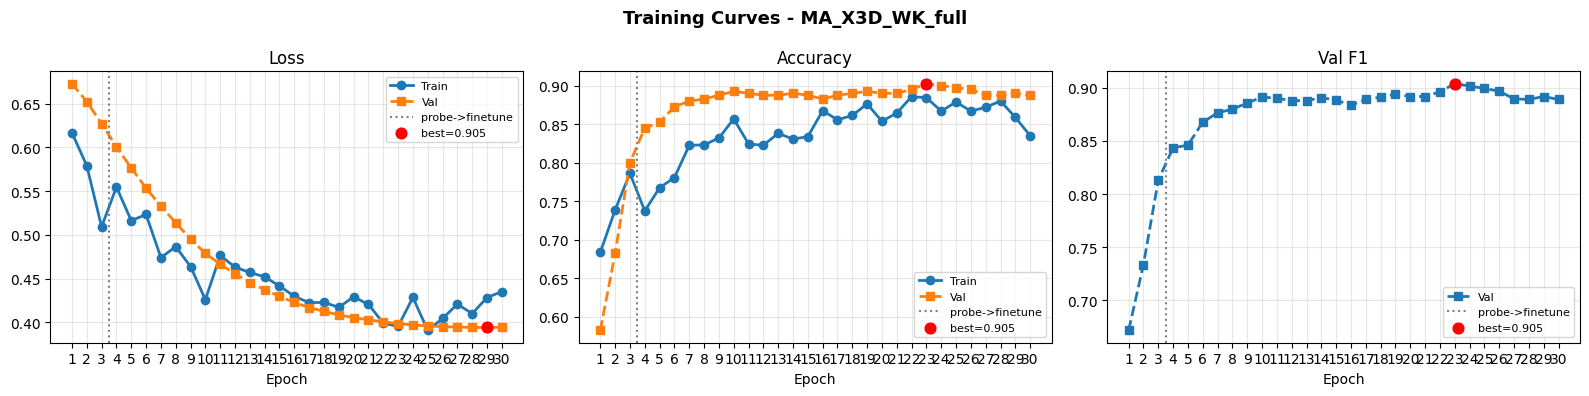


Best val_f1=0.9037  (val_loss=0.3984)
  [INFO] All epochs already complete — no new val run.

Final eval -> official held-out (400)


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


  widened 8 early-stage conv_b -> 5x5 (v2 reparam, stages (1, 2))
  finetune unfreeze: ['blocks.1', 'blocks.2']  | new-LR keywords: ('delta_weight',)  [ring -> LR_MA]


In [ ]:
import json as _json

TRAIN_HDF5_LIST = [RWF_TRAIN_HDF5]

# Guard
missing = [p for p in TRAIN_HDF5_LIST + [RWF_VAL_HDF5] if not os.path.exists(p)]
if missing:
    for p in missing: print(f"  [X]  {p}")
    raise FileNotFoundError("Build HDF5 first")

print("HDF5 verified:")
for p in TRAIN_HDF5_LIST + [RWF_VAL_HDF5]:
    print(f"  [OK] {p.split('/')[-1]}  ({os.path.getsize(p)/1e6:.0f} MB)")

# Datasets
print("\nLoading datasets...")
train_ds = HDF5VideoDataset(
    TRAIN_HDF5_LIST,
    transform=VideoTransform(training=True),
    num_stored=NUM_FRAMES_STORED, num_sample=NUM_FRAMES_SAMPLE,
    training=True, augment_multiplier=AUGMENT_MULTIPLIER
)
test_ds = HDF5VideoDataset(
    [RWF_VAL_HDF5],
    transform=VideoTransform(training=False),
    num_stored=NUM_FRAMES_STORED, num_sample=NUM_FRAMES_SAMPLE,
    training=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

# ============================================================================
# FULL-DATA training (NO K-fold): train on ALL 1600 train clips, use the
# official 400-clip RWF val as the validation set for early stopping and
# best-checkpoint selection. Report the best val (= official held-out).
# Matches standard single-split reporting on RWF-2000 (WK v2 / reparam).
# ============================================================================
EXPERIMENT = 'MA_X3D_WK_full'     # distinct name -> won't clash with fold runs

RESET_FULL = False                 # <<< set False on a 2nd session to RESUME
if RESET_FULL:
    _n = 0
    for _f in (os.listdir(CHECKPOINT_DIR) if os.path.exists(CHECKPOINT_DIR) else []):
        if EXPERIMENT in _f:
            os.remove(os.path.join(CHECKPOINT_DIR, _f)); _n += 1
    print(f"[RESET_FULL] removed {_n} '{EXPERIMENT}' file(s)")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    persistent_workers=True, prefetch_factor=6)

print(f"\n{'='*60}")
print(f"  FULL-DATA RUN (WK v2)  "
      f"train={len(train_ds)} (={train_ds.base_len}x{train_ds.augment_multiplier})  "
      f"val/test={len(test_ds)} (official held-out)")
print(f"{'='*60}")

model = get_ma_x3d_widekernel_model()
_, best_path = train_model(model, train_loader, test_loader, experiment_name=EXPERIMENT)

# Final eval of the best checkpoint on the official held-out val (400)
print(f"\nFinal eval -> official held-out (400)")
device = torch.device(DEVICE)
eval_m = get_ma_x3d_widekernel_model()
raw_sd = torch.load(best_path, map_location=device, weights_only=True)
clean_sd = {k.replace('_orig_mod.', '').replace('module.', ''): v for k, v in raw_sd.items()}
eval_m.load_state_dict(clean_sd)
eval_m.to(device).eval()

all_p, all_l, correct, total = [], [], 0, 0
with torch.no_grad():
    for inputs, motion, labels in test_loader:
        inputs, motion, labels = inputs.to(device), motion.to(device), labels.to(device)
        pred = eval_m(inputs, motion).argmax(1)
        correct += (pred == labels).sum().item(); total += labels.size(0)
        all_p.extend(pred.cpu().numpy()); all_l.extend(labels.cpu().numpy())
acc = correct / total
_, _, f1, _ = precision_recall_fscore_support(all_l, all_p, average='binary', zero_division=0)
#print(f"  [HELD-OUT] Acc={acc:.4f}  F1={f1:.4f}  (n={total})")
#(classification_report(all_l, all_p, labels=[0, 1], target_names=['NonFight', 'Fight']))

print("\n--- widekernel_report (proof the outer ring trained) ---")
widekernel_report(eval_m)
_es = [outer_ring_energy(rb.branch2.conv_b)
       for s in EARLY_STAGES for rb in eval_m.blocks[s].res_blocks
       if hasattr(rb.branch2, 'conv_b') and rb.branch2.conv_b.kernel_size[1] > 3]
if _es:
    print(f"  mean outer_ring_energy = {np.mean(_es):.4f}  (>= 0.05 means widening is used)")